# Telco customers Churn prediction model

### Introduction
Losing a telecom customer costs far more than keeping one. With this project, we analyze historical company data to predict which users are at a high risk of leaving (churning). Our live web service takes a customer's profile in real-time and instantly calculates their churn probability. This allows the business team to step in immediately and offer personalized retention incentives before the customer decides to cancel their service.


## Exploratory Data Analysis

Load libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap

### Data Loading & Initial Exploration

In [7]:
import os
import pandas as pd

try:
    import kagglehub
    from kagglehub import KaggleDatasetAdapter

    dataset_path = kagglehub.dataset_download("blastchar/telco-customer-churn")
    csv_files = [
        os.path.join(dataset_path, f)
        for f in os.listdir(dataset_path)
        if f.lower().endswith((".csv", ".tsv", ".json", ".jsonl", ".parquet", ".feather", ".xlsx", ".xls"))
    ]

    if csv_files:
        df = pd.read_csv(csv_files[0])
    else:
        raise FileNotFoundError("No supported data file was found in the downloaded dataset.")
except Exception as e:
    print(f"Falling back to public CSV source: {e}")
    url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
    df = pd.read_csv(url)

print("First 5 records:")
print(df.head())

Falling back to public CSV source: HTTPSConnectionPool(host='api.kaggle.com', port=443): Max retries exceeded with url: /v1/datasets.DatasetApiService/GetDataset (Caused by SSLError(SSLCertVerificationError(1, '[SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: self-signed certificate in certificate chain (_ssl.c:1081)')))
First 5 records:
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1               

In [8]:
print(f"Dataset Shape: {df.shape}")

Dataset Shape: (7043, 21)


In [9]:
print("\nData Types:")
print(df.dtypes)


Data Types:
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object


In [10]:
print("\nStatistical Summary:")
display(df.describe(include='all'))


Statistical Summary:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,...,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,...,3,3,3,3,3,2,4,NaN,6531,2
top,7590-VHVEG,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,20.2,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,...,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN


In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

/var/folders/h3/fl0y961s4hz1hxq301qt9xzw0000gp/T/ipykernel_52313/3728821728.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='tenure', data=df, ax=axes[0, 1], palette='Set2')
/var/folders/h3/fl0y961s4hz1hxq301qt9xzw0000gp/T/ipykernel_52313/3728821728.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='MonthlyCharges', data=df, ax=axes[1, 0], palette='Set2')


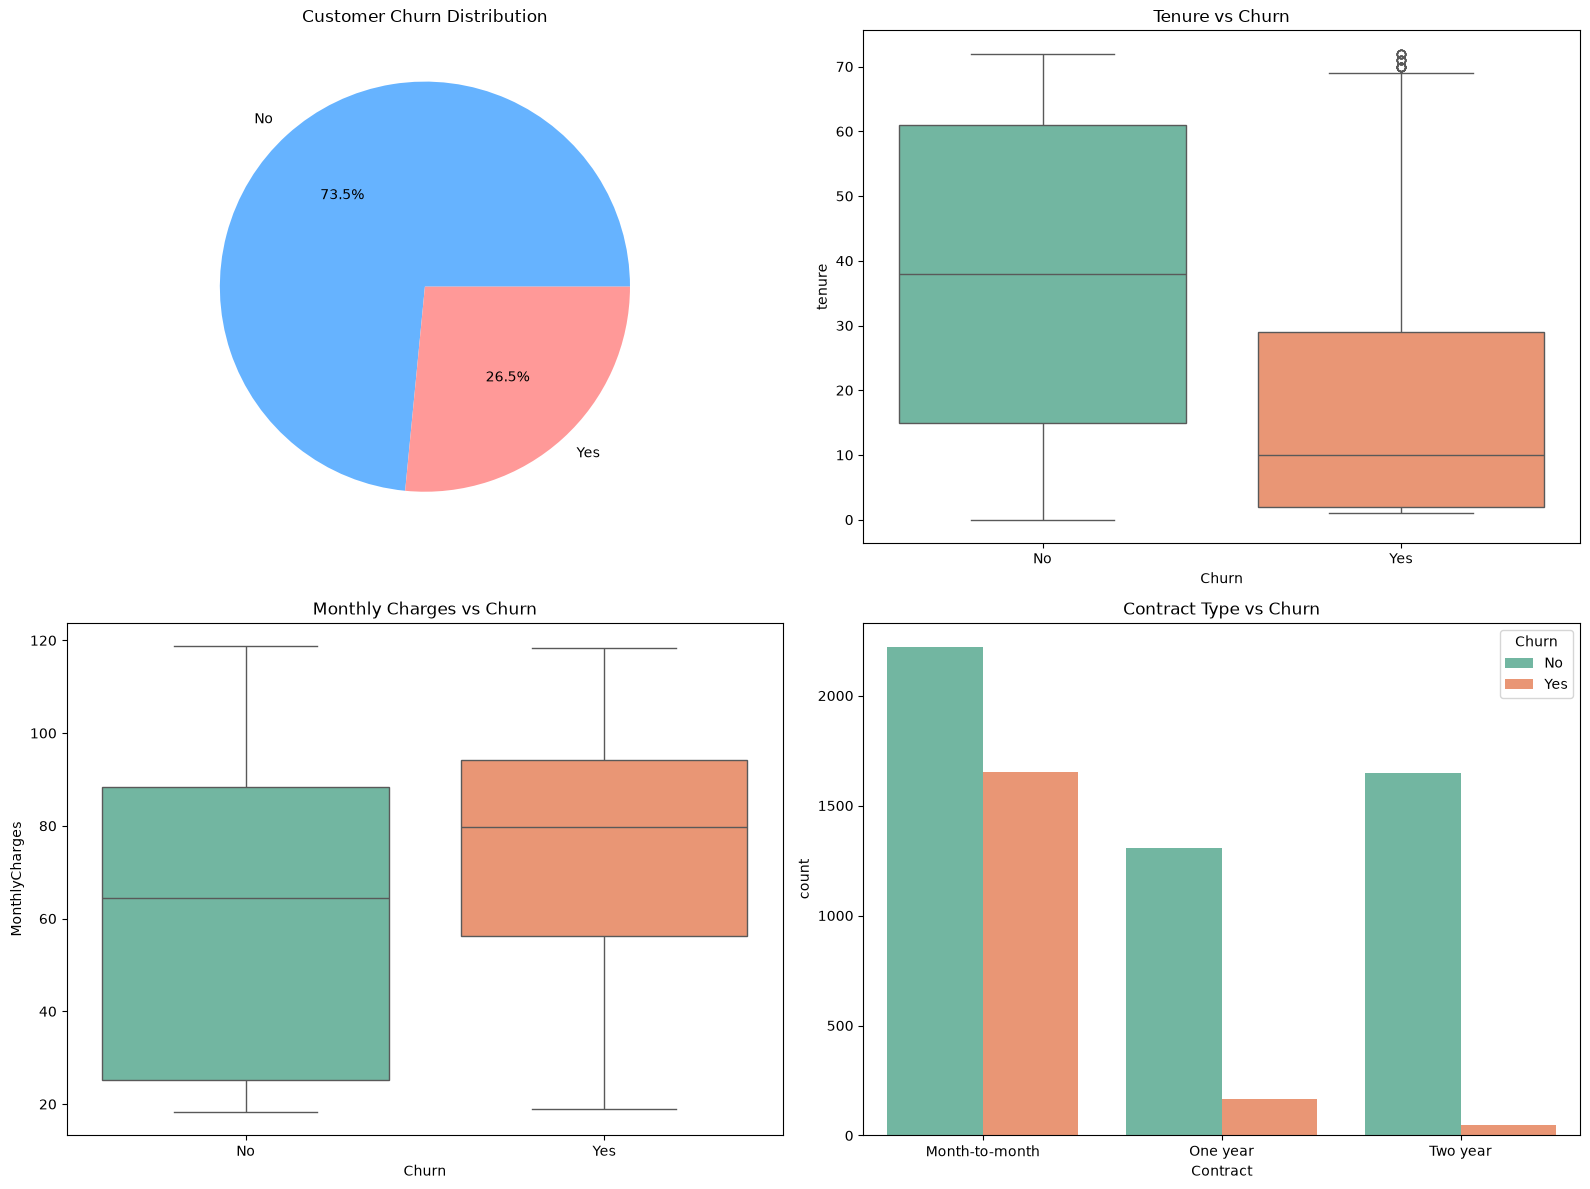

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Churn Rate Pie Chart
df['Churn'].value_counts().plot(kind='pie', autopct='%1.1f%%', ax=axes[0, 0], colors=['#66b3ff', '#ff9998'])
axes[0, 0].set_title('Customer Churn Distribution')
axes[0, 0].set_ylabel('')

# 2. Churn vs Tenure
sns.boxplot(x='Churn', y='tenure', data=df, ax=axes[0, 1], palette='Set2')
axes[0, 1].set_title('Tenure vs Churn')

# 3. Monthly Charges vs Churn
sns.boxplot(x='Churn', y='MonthlyCharges', data=df, ax=axes[1, 0], palette='Set2')
axes[1, 0].set_title('Monthly Charges vs Churn')

# 4. Contract Type vs Churn (Countplot)
sns.countplot(x='Contract', hue='Churn', data=df, ax=axes[1, 1], palette='Set2')
axes[1, 1].set_title('Contract Type vs Churn')

plt.tight_layout()
plt.show()


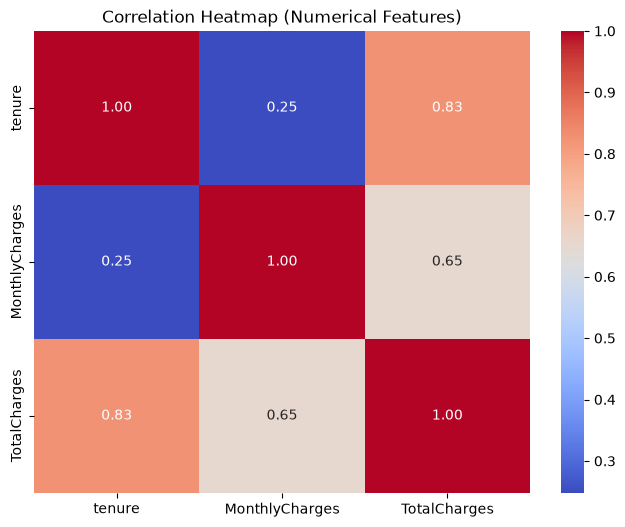

In [ ]:
# Correlation Heatmap
temp_df = df.copy()
temp_df['TotalCharges'] = pd.to_numeric(temp_df['TotalCharges'], errors='coerce')
plt.figure(figsize=(8, 6))
sns.heatmap(temp_df[['tenure', 'MonthlyCharges', 'TotalCharges']].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap (Numerical Features)')
plt.show()
